# 5.5.2 PD Subject Clustering Analysis

This notebook performs clustering analysis specifically on **Parkinson's Disease (PD) subjects** to identify distinct patient subtypes based on VAE latent representations.

## Key Differences from 5.5.1

1. **Focus on PD Subjects Only**: We filter to include only PD subjects (~80% of the dataset)
2. **No PCA for Dimensionality Reduction**: β-VAE latent dimensions are intentionally maximally independent, so PCA is not effective
3. **Cluster Separation Metrics**: Multiple metrics to quantify cluster quality
4. **Validation Dataset Testing**: Validate discovered clusters on held-out data
5. **Correlation Analysis with Clinical Factors**: Check if clusters correlate with known demographics/SBR (hoping they don't!)

## Methodology

1. **Data Loading**: Load latent representations for training and validation sets
2. **PD Subject Filtering**: Keep only PD subjects
3. **Clustering on Raw Latent Space**: Use active (KL > threshold) dimensions directly
4. **Multiple Clustering Algorithms**: K-Means, GMM, Hierarchical, DBSCAN
5. **Cluster Quality Metrics**:
   - Silhouette Score (higher is better, range -1 to 1)
   - Davies-Bouldin Index (lower is better)
   - Calinski-Harabasz Index (higher is better)
6. **Validation on Test Set**: Apply trained clustering to validation data
7. **Clinical Factor Analysis**: Test correlation with Age, Sex, Scanner, SBR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy import stats
import os
import warnings

# Optional: UMAP (install with: pip install umap-learn)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("Warning: UMAP not installed. Install with: pip install umap-learn")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: '%.4f' % x)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data Loading

In [4]:
# --- PARAMETERS ---
TRAIN_LATENT_CSV = "output/final_train_combined_vae_data.csv"
VAL_LATENT_CSV = "output/final_validation_combined_vae_data.csv"  # Validation dataset
KL_CSV_PATH = "output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-05/kl_divergence.csv"
KL_THRESHOLD = 0.05

# SBR columns for analysis
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Load Training Data
if os.path.exists(TRAIN_LATENT_CSV):
    df_train = pd.read_csv(TRAIN_LATENT_CSV)
    print(f"Loaded Training Data: {df_train.shape}")
else:
    raise FileNotFoundError(f"Training data not found at {TRAIN_LATENT_CSV}")

# Load Validation Data
if os.path.exists(VAL_LATENT_CSV):
    df_val = pd.read_csv(VAL_LATENT_CSV)
    print(f"Loaded Validation Data: {df_val.shape}")
else:
    print(f"Validation data not found at {VAL_LATENT_CSV}")
    df_val = None

# Define Latent Columns
DIM_COLS = [c for c in df_train.columns if c.startswith('latent_')]
print(f"Total Latent Dimensions: {len(DIM_COLS)}")

Loaded Training Data: (2373, 303)
Loaded Validation Data: (591, 303)
Total Latent Dimensions: 256


## 2. Filter PD Subjects Only

In [5]:
# Filter to PD subjects only
df_train_pd = df_train[df_train['label'] == 'PD'].copy()
print(f"PD Subjects in Training Set: {len(df_train_pd)} ({len(df_train_pd)/len(df_train)*100:.1f}%)")
print(f"Unique PD Patients: {df_train_pd['PATNO'].nunique()}")

if df_val is not None:
    df_val_pd = df_val[df_val['label'] == 'PD'].copy()
    print(f"PD Subjects in Validation Set: {len(df_val_pd)} ({len(df_val_pd)/len(df_val)*100:.1f}%)")
    print(f"Unique PD Patients (Val): {df_val_pd['PATNO'].nunique()}")
else:
    df_val_pd = None

# Show label distribution
print(f"\nOriginal Label Distribution (Train):")
print(df_train['label'].value_counts())

PD Subjects in Training Set: 2030 (85.5%)
Unique PD Patients: 1136
PD Subjects in Validation Set: 508 (86.0%)
Unique PD Patients (Val): 438

Original Label Distribution (Train):
label
PD         2030
Control     233
SWEDD       110
Name: count, dtype: int64


## 3. Identify Active Latent Dimensions (No PCA)

Since β-VAE latent dimensions are designed to be maximally independent, PCA is not effective for dimensionality reduction.
Instead, we use KL-divergence filtering to identify **active** dimensions.

In [6]:
# Identify Active Dimensions using KL Divergence
active_dims = []

if os.path.exists(KL_CSV_PATH):
    df_kl = pd.read_csv(KL_CSV_PATH)
    active_dims = df_kl[df_kl['mean_kl'] > KL_THRESHOLD]['dimension'].tolist()
    print(f"Using KL Divergence filtering from: {KL_CSV_PATH}")
    print(f"Active Dimensions (KL > {KL_THRESHOLD}): {len(active_dims)}")
else:
    # Fallback to Variance
    variances = df_train_pd[DIM_COLS].var()
    active_dims = variances[variances > KL_THRESHOLD].index.tolist()
    print(f"Using Variance as proxy for activity (KL file not found)")
    print(f"Active Dimensions (Var > {KL_THRESHOLD}): {len(active_dims)}")

ACTIVE_FEATURES = sorted(active_dims, key=lambda x: int(x.split('_')[1]))
print(f"\nFeatures used for clustering: {len(ACTIVE_FEATURES)} dimensions")
print(f"First 10: {ACTIVE_FEATURES[:10]}")

Using KL Divergence filtering from: output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-05/kl_divergence.csv
Active Dimensions (KL > 0.05): 67

Features used for clustering: 67 dimensions
First 10: ['latent_6', 'latent_8', 'latent_10', 'latent_17', 'latent_18', 'latent_19', 'latent_22', 'latent_23', 'latent_27', 'latent_34']


## 4. Feature Engineering: SBR Principal Components

In [7]:
# Create SBR Principal Components for PD subjects
df_pd_with_sbr = df_train_pd.dropna(subset=SBR_COLS).copy()
print(f"PD Rows with complete SBR data: {len(df_pd_with_sbr)}")

scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_pd_with_sbr[SBR_COLS])
pca_sbr = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca_sbr.fit_transform(sbr_scaled)

df_pd_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_pd_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_pd_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca_sbr.explained_variance_ratio_}")
print(f"Total variance explained: {pca_sbr.explained_variance_ratio_.sum():.2%}")

# Final dataset for clustering
df_pd_final = df_pd_with_sbr.reset_index(drop=True)
print(f"\nFinal PD dataset: {df_pd_final.shape}")
print(f"Unique patients: {df_pd_final['PATNO'].nunique()}")

PD Rows with complete SBR data: 2030

SBR PCA explained variance: [0.8245461  0.09548108 0.05841849]
Total variance explained: 97.84%

Final PD dataset: (2030, 306)
Unique patients: 1136


## 5. Prepare Data for Clustering (No PCA)

In [8]:
# Standardize the active latent features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pd_final[ACTIVE_FEATURES])

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"\nNote: Using raw latent dimensions (no PCA) since β-VAE dimensions are already independent.")

# UMAP for visualization only (not for clustering)
X_umap = None
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, 
                       n_neighbors=15, min_dist=0.1, metric='euclidean')
    X_umap = reducer.fit_transform(X_scaled)
    print(f"\nUMAP embedding for visualization: {X_umap.shape}")

Feature matrix shape: (2030, 67)

Note: Using raw latent dimensions (no PCA) since β-VAE dimensions are already independent.

UMAP embedding for visualization: (2030, 2)


## 6. Cluster Quality Metrics Functions

In [9]:
def compute_cluster_metrics(X, labels):
    """
    Compute multiple cluster quality metrics.
    
    Returns:
        dict: Dictionary with metric names and values
    """
    metrics = {}
    
    # Remove noise points (label=-1 for DBSCAN)
    valid_mask = labels >= 0
    X_valid = X[valid_mask]
    labels_valid = labels[valid_mask]
    
    n_clusters = len(np.unique(labels_valid))
    
    if n_clusters < 2 or n_clusters >= len(X_valid):
        return {'silhouette': np.nan, 'davies_bouldin': np.nan, 'calinski_harabasz': np.nan, 'n_clusters': n_clusters}
    
    # Silhouette Score: measures how similar objects are to their cluster vs other clusters
    # Range: -1 to 1, higher is better
    metrics['silhouette'] = silhouette_score(X_valid, labels_valid)
    
    # Davies-Bouldin Index: measures average similarity between clusters
    # Lower is better (0 = best)
    metrics['davies_bouldin'] = davies_bouldin_score(X_valid, labels_valid)
    
    # Calinski-Harabasz Index: ratio of between-cluster to within-cluster variance
    # Higher is better
    metrics['calinski_harabasz'] = calinski_harabasz_score(X_valid, labels_valid)
    
    metrics['n_clusters'] = n_clusters
    
    return metrics

def print_metrics(metrics, algo_name):
    """Pretty print cluster metrics"""
    print(f"\n{algo_name} Cluster Quality Metrics:")
    print(f"  - Number of Clusters: {metrics['n_clusters']}")
    print(f"  - Silhouette Score: {metrics['silhouette']:.4f} (higher is better, range -1 to 1)")
    print(f"  - Davies-Bouldin Index: {metrics['davies_bouldin']:.4f} (lower is better)")
    print(f"  - Calinski-Harabasz Index: {metrics['calinski_harabasz']:.2f} (higher is better)")

## 7. Find Optimal Number of Clusters

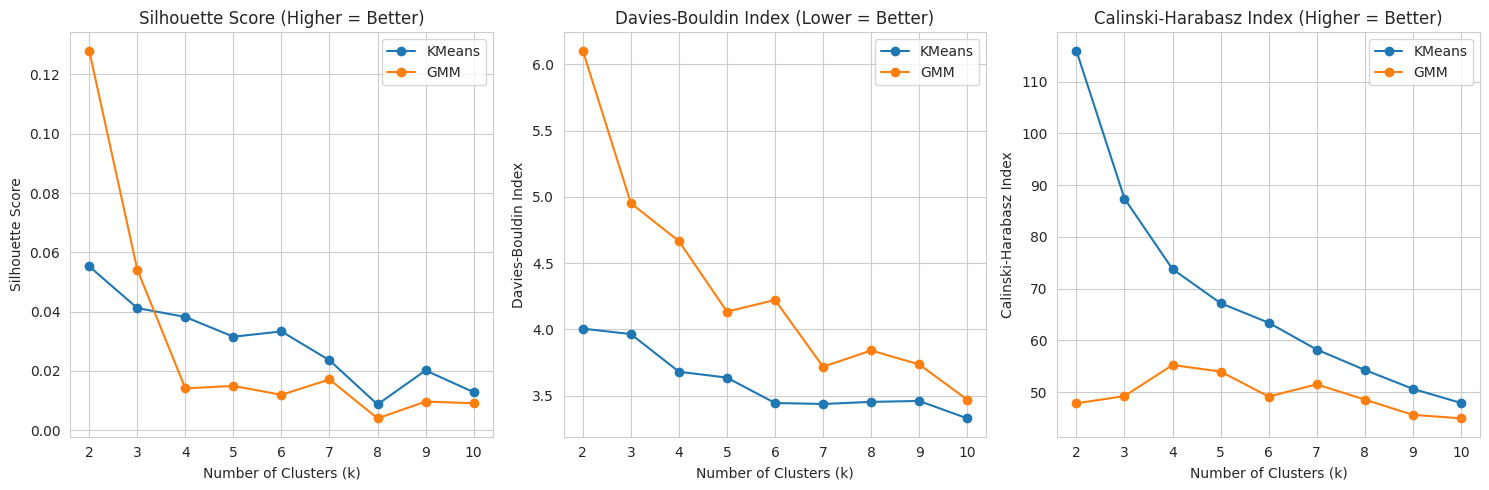


Best configuration based on Silhouette Score:
  Algorithm: GMM
  k = 2
  Silhouette: 0.1280


In [10]:
# Scan different values of k
k_range = range(2, 11)
results = []

for k in k_range:
    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_km = kmeans.fit_predict(X_scaled)
    metrics_km = compute_cluster_metrics(X_scaled, labels_km)
    metrics_km['k'] = k
    metrics_km['algorithm'] = 'KMeans'
    results.append(metrics_km)
    
    # GMM
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=3)
    labels_gmm = gmm.fit_predict(X_scaled)
    metrics_gmm = compute_cluster_metrics(X_scaled, labels_gmm)
    metrics_gmm['k'] = k
    metrics_gmm['algorithm'] = 'GMM'
    results.append(metrics_gmm)

df_results = pd.DataFrame(results)

# Plot metrics vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for algo in ['KMeans', 'GMM']:
    df_algo = df_results[df_results['algorithm'] == algo]
    axes[0].plot(df_algo['k'], df_algo['silhouette'], 'o-', label=algo)
    axes[1].plot(df_algo['k'], df_algo['davies_bouldin'], 'o-', label=algo)
    axes[2].plot(df_algo['k'], df_algo['calinski_harabasz'], 'o-', label=algo)

axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score (Higher = Better)')
axes[0].legend()

axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index (Lower = Better)')
axes[1].legend()

axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('Calinski-Harabasz Index (Higher = Better)')
axes[2].legend()

plt.tight_layout()
plt.savefig('output/pd_clustering_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Find best k based on silhouette score
best_k_row = df_results.loc[df_results['silhouette'].idxmax()]
print(f"\nBest configuration based on Silhouette Score:")
print(f"  Algorithm: {best_k_row['algorithm']}")
print(f"  k = {int(best_k_row['k'])}")
print(f"  Silhouette: {best_k_row['silhouette']:.4f}")

## 8. Apply Best Clustering Algorithm

In [11]:
# Select number of clusters based on analysis
OPTIMAL_K = 2  # Adjust based on the plots above

# Train multiple clustering models
clustering_results = {}

# K-Means
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
metrics_kmeans = compute_cluster_metrics(X_scaled, labels_kmeans)
clustering_results['KMeans'] = {'model': kmeans, 'labels': labels_kmeans, 'metrics': metrics_kmeans}
print_metrics(metrics_kmeans, 'K-Means')

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=OPTIMAL_K, random_state=RANDOM_STATE, n_init=3, covariance_type='full')
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)
metrics_gmm = compute_cluster_metrics(X_scaled, labels_gmm)
clustering_results['GMM'] = {'model': gmm, 'labels': labels_gmm, 'metrics': metrics_gmm}
print_metrics(metrics_gmm, 'GMM')

# Hierarchical Clustering
hier = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
labels_hier = hier.fit_predict(X_scaled)
metrics_hier = compute_cluster_metrics(X_scaled, labels_hier)
clustering_results['Hierarchical'] = {'model': hier, 'labels': labels_hier, 'metrics': metrics_hier}
print_metrics(metrics_hier, 'Hierarchical')

# Store best result in DataFrame
best_algo = max(clustering_results, key=lambda x: clustering_results[x]['metrics']['silhouette'])
print(f"\n\n=== Best Algorithm: {best_algo} ===")
df_pd_final['cluster'] = clustering_results[best_algo]['labels']


K-Means Cluster Quality Metrics:
  - Number of Clusters: 2
  - Silhouette Score: 0.0553 (higher is better, range -1 to 1)
  - Davies-Bouldin Index: 4.0052 (lower is better)
  - Calinski-Harabasz Index: 115.97 (higher is better)

GMM Cluster Quality Metrics:
  - Number of Clusters: 2
  - Silhouette Score: 0.1280 (higher is better, range -1 to 1)
  - Davies-Bouldin Index: 6.1026 (lower is better)
  - Calinski-Harabasz Index: 47.84 (higher is better)

Hierarchical Cluster Quality Metrics:
  - Number of Clusters: 2
  - Silhouette Score: 0.0907 (higher is better, range -1 to 1)
  - Davies-Bouldin Index: 4.4874 (lower is better)
  - Calinski-Harabasz Index: 70.57 (higher is better)


=== Best Algorithm: GMM ===


## 9. Visualize Clusters

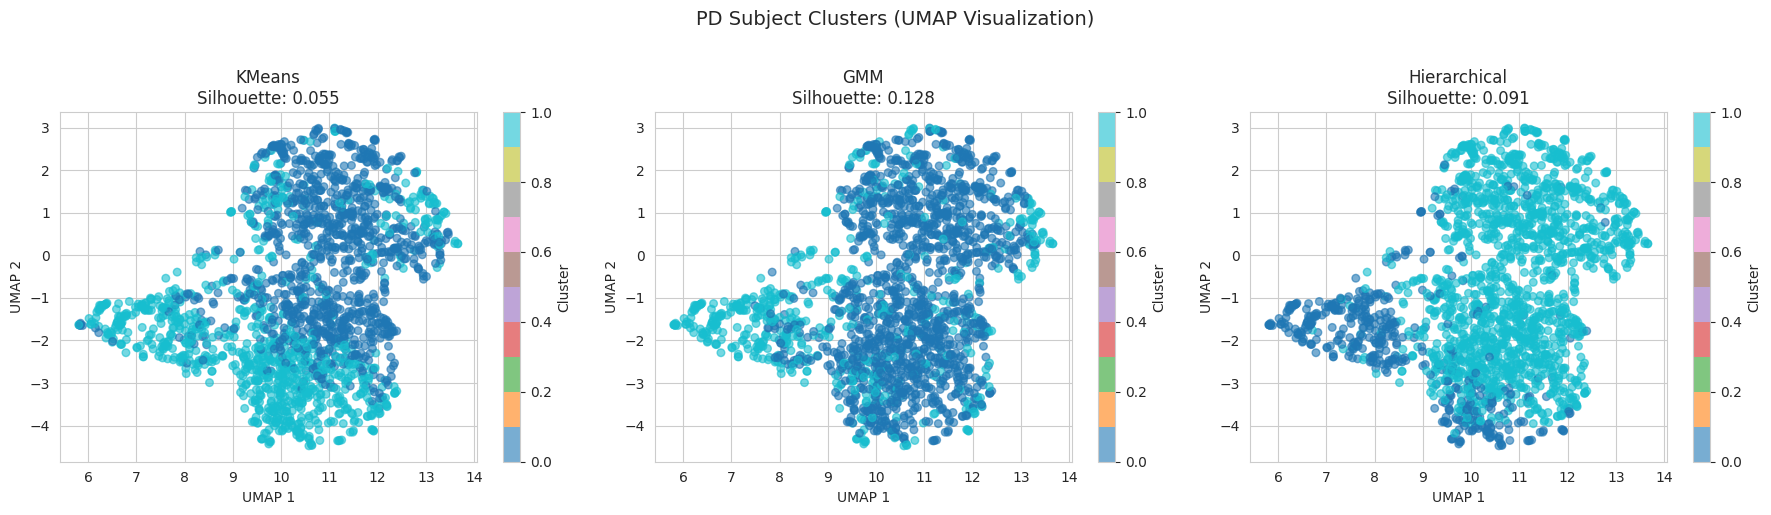

In [12]:
if X_umap is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (algo_name, result) in enumerate(clustering_results.items()):
        scatter = axes[idx].scatter(X_umap[:, 0], X_umap[:, 1], 
                                    c=result['labels'], cmap='tab10', alpha=0.6, s=30)
        axes[idx].set_xlabel('UMAP 1')
        axes[idx].set_ylabel('UMAP 2')
        axes[idx].set_title(f"{algo_name}\nSilhouette: {result['metrics']['silhouette']:.3f}")
        plt.colorbar(scatter, ax=axes[idx], label='Cluster')
    
    plt.suptitle('PD Subject Clusters (UMAP Visualization)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('output/pd_clusters_umap_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("UMAP not available for visualization.")

## 10. Cluster Distribution Analysis

Cluster Distribution:
cluster
0    1468
1     562
Name: count, dtype: int64

Cluster Proportions:
cluster
0   72.3153
1   27.6847
Name: count, dtype: float64


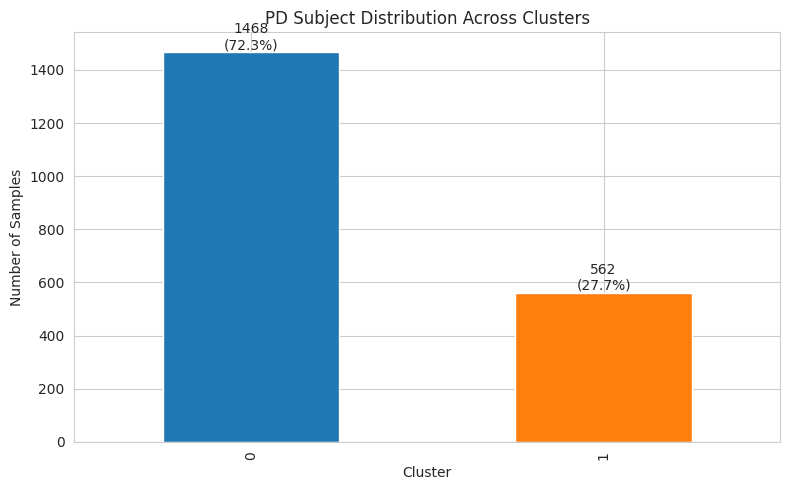

In [13]:
# Cluster distribution
cluster_counts = df_pd_final['cluster'].value_counts().sort_index()
print("Cluster Distribution:")
print(cluster_counts)
print(f"\nCluster Proportions:")
print(cluster_counts / len(df_pd_final) * 100)

fig, ax = plt.subplots(figsize=(8, 5))
cluster_counts.plot(kind='bar', ax=ax, color=plt.cm.tab10(np.arange(len(cluster_counts))))
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Samples')
ax.set_title('PD Subject Distribution Across Clusters')
for i, v in enumerate(cluster_counts):
    ax.text(i, v + 10, f'{v}\n({v/len(df_pd_final)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('output/pd_cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Silhouette Analysis per Sample

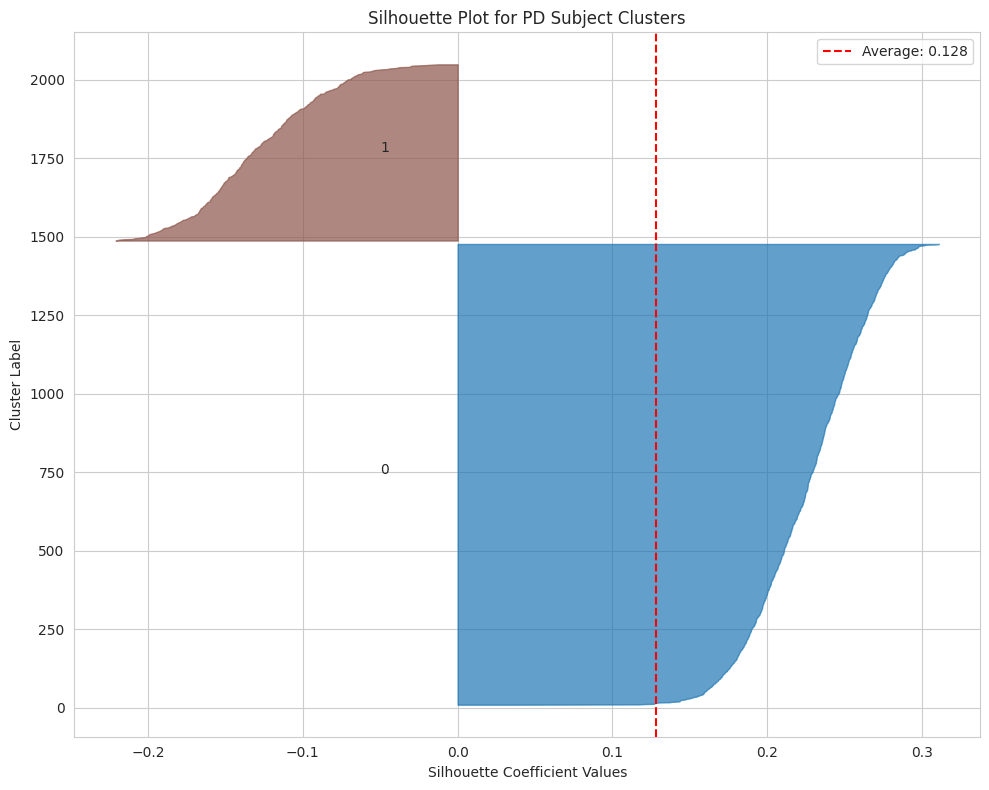

In [14]:
# Compute silhouette values for each sample
silhouette_vals = silhouette_samples(X_scaled, df_pd_final['cluster'])

fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
for i in range(OPTIMAL_K):
    cluster_silhouette_vals = silhouette_vals[df_pd_final['cluster'] == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = len(cluster_silhouette_vals)
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.tab10(i / OPTIMAL_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

avg_silhouette = clustering_results[best_algo]['metrics']['silhouette']
ax.axvline(x=avg_silhouette, color="red", linestyle="--", label=f'Average: {avg_silhouette:.3f}')
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster Label')
ax.set_title('Silhouette Plot for PD Subject Clusters')
ax.legend()
plt.tight_layout()
plt.savefig('output/pd_silhouette_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Validation on Test Dataset

=== Validation Dataset Analysis ===
Validation PD samples with complete SBR: 508

GMM on Validation Set Cluster Quality Metrics:
  - Number of Clusters: 2
  - Silhouette Score: 0.1311 (higher is better, range -1 to 1)
  - Davies-Bouldin Index: 6.3907 (lower is better)
  - Calinski-Harabasz Index: 10.42 (higher is better)

Cluster Distribution Comparison:
         Train (%)  Validation (%)
cluster                           
0          72.3153         75.5906
1          27.6847         24.4094


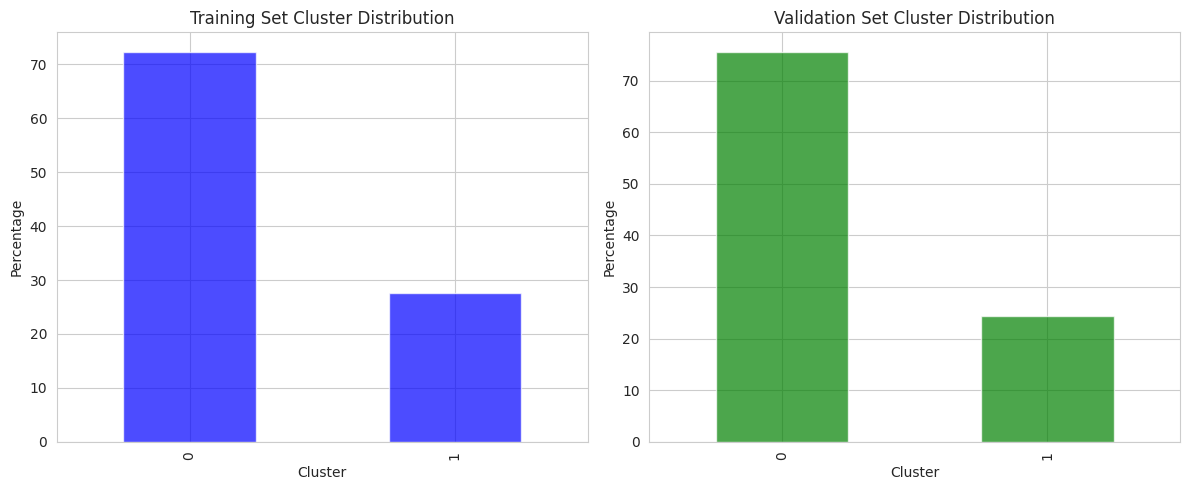

In [15]:
if df_val_pd is not None and len(df_val_pd) > 0:
    print("=== Validation Dataset Analysis ===")
    
    # Prepare validation data (only with complete SBR data)
    df_val_pd_clean = df_val_pd.dropna(subset=SBR_COLS).copy()
    print(f"Validation PD samples with complete SBR: {len(df_val_pd_clean)}")
    
    if len(df_val_pd_clean) > 10:  # Need enough samples
        # Scale validation data using training scaler
        X_val_scaled = scaler.transform(df_val_pd_clean[ACTIVE_FEATURES])
        
        # Predict clusters using trained model
        best_model = clustering_results[best_algo]['model']
        
        if best_algo == 'KMeans':
            labels_val = best_model.predict(X_val_scaled)
        elif best_algo == 'GMM':
            labels_val = best_model.predict(X_val_scaled)
        else:  # Hierarchical - need to refit or use nearest neighbor
            # Use K-Means centroids as proxy
            kmeans_proxy = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
            kmeans_proxy.fit(X_scaled)
            labels_val = kmeans_proxy.predict(X_val_scaled)
        
        df_val_pd_clean['cluster'] = labels_val
        
        # Compute metrics on validation set
        metrics_val = compute_cluster_metrics(X_val_scaled, labels_val)
        print_metrics(metrics_val, f'{best_algo} on Validation Set')
        
        # Compare cluster distributions
        print("\nCluster Distribution Comparison:")
        train_dist = df_pd_final['cluster'].value_counts(normalize=True).sort_index()
        val_dist = df_val_pd_clean['cluster'].value_counts(normalize=True).sort_index()
        
        comparison_df = pd.DataFrame({
            'Train (%)': train_dist * 100,
            'Validation (%)': val_dist * 100
        })
        print(comparison_df)
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        comparison_df['Train (%)'].plot(kind='bar', ax=axes[0], color='blue', alpha=0.7)
        axes[0].set_title('Training Set Cluster Distribution')
        axes[0].set_xlabel('Cluster')
        axes[0].set_ylabel('Percentage')
        
        comparison_df['Validation (%)'].plot(kind='bar', ax=axes[1], color='green', alpha=0.7)
        axes[1].set_title('Validation Set Cluster Distribution')
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Percentage')
        
        plt.tight_layout()
        plt.savefig('output/pd_cluster_validation_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("Not enough validation samples for analysis.")
else:
    print("Validation dataset not available.")

## 13. Correlation with Demographics and Clinical Factors

**Note**: We are hoping that clusters do NOT strongly correlate with known factors (Age, Sex, Scanner, SBR),
as this would suggest we've discovered new, unknown subtypes!

In [16]:
# Analyze correlation with demographics
print("=== Correlation Analysis with Known Factors ===")
print("(Low correlation is GOOD - suggests novel subtypes!)\n")

correlation_results = []

# Age (continuous) - ANOVA
if 'Age' in df_pd_final.columns:
    groups = [df_pd_final[df_pd_final['cluster'] == i]['Age'].dropna() for i in range(OPTIMAL_K)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        # Effect size (eta-squared)
        ss_between = sum(len(g) * (g.mean() - df_pd_final['Age'].mean())**2 for g in groups)
        ss_total = sum((df_pd_final['Age'].dropna() - df_pd_final['Age'].mean())**2)
        eta_sq = ss_between / ss_total if ss_total > 0 else 0
        
        correlation_results.append({
            'Factor': 'Age', 'Test': 'ANOVA', 'Statistic': f_stat, 
            'p-value': p_val, 'Effect Size (η²)': eta_sq
        })
        print(f"Age: F={f_stat:.3f}, p={p_val:.4f}, η²={eta_sq:.4f}")

# Sex (binary) - Chi-square
if 'Sex' in df_pd_final.columns:
    contingency = pd.crosstab(df_pd_final['cluster'], df_pd_final['Sex'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    cramers_v = np.sqrt(chi2 / (len(df_pd_final) * (min(contingency.shape) - 1)))
    
    correlation_results.append({
        'Factor': 'Sex', 'Test': 'Chi-square', 'Statistic': chi2,
        'p-value': p_val, 'Effect Size (Cramér\'s V)': cramers_v
    })
    print(f"Sex: χ²={chi2:.3f}, p={p_val:.4f}, Cramér's V={cramers_v:.4f}")

# Scanner/Manufacturer (categorical) - Chi-square
for cat_col in ['scanner', 'Scanner', 'Manufacturer', 'manufacturer']:
    if cat_col in df_pd_final.columns:
        contingency = pd.crosstab(df_pd_final['cluster'], df_pd_final[cat_col])
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
            cramers_v = np.sqrt(chi2 / (len(df_pd_final) * (min(contingency.shape) - 1)))
            
            correlation_results.append({
                'Factor': cat_col, 'Test': 'Chi-square', 'Statistic': chi2,
                'p-value': p_val, 'Effect Size (Cramér\'s V)': cramers_v
            })
            print(f"{cat_col}: χ²={chi2:.3f}, p={p_val:.4f}, Cramér's V={cramers_v:.4f}")

# SBR Principal Components (continuous) - ANOVA
for sbr_pc in ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']:
    if sbr_pc in df_pd_final.columns:
        groups = [df_pd_final[df_pd_final['cluster'] == i][sbr_pc].dropna() for i in range(OPTIMAL_K)]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            f_stat, p_val = stats.f_oneway(*groups)
            ss_between = sum(len(g) * (g.mean() - df_pd_final[sbr_pc].mean())**2 for g in groups)
            ss_total = sum((df_pd_final[sbr_pc].dropna() - df_pd_final[sbr_pc].mean())**2)
            eta_sq = ss_between / ss_total if ss_total > 0 else 0
            
            correlation_results.append({
                'Factor': sbr_pc, 'Test': 'ANOVA', 'Statistic': f_stat,
                'p-value': p_val, 'Effect Size (η²)': eta_sq
            })
            print(f"{sbr_pc}: F={f_stat:.3f}, p={p_val:.4f}, η²={eta_sq:.4f}")

=== Correlation Analysis with Known Factors ===
(Low correlation is GOOD - suggests novel subtypes!)

Manufacturer: χ²=311.487, p=0.0000, Cramér's V=0.3917
SBR_PC1: F=120.501, p=0.0000, η²=0.0561
SBR_PC2: F=0.000, p=0.9974, η²=0.0000
SBR_PC3: F=7.306, p=0.0069, η²=0.0036


In [17]:
# Summary table
if correlation_results:
    df_corr = pd.DataFrame(correlation_results)
    print("\n=== Correlation Summary ===")
    print(df_corr.to_string(index=False))
    
    # Interpretation
    print("\n=== Interpretation ===")
    sig_threshold = 0.05
    sig_factors = df_corr[df_corr['p-value'] < sig_threshold]
    nonsig_factors = df_corr[df_corr['p-value'] >= sig_threshold]
    
    if len(sig_factors) > 0:
        print(f"Factors with SIGNIFICANT cluster differences (p < {sig_threshold}):")
        for _, row in sig_factors.iterrows():
            print(f"  - {row['Factor']} (p={row['p-value']:.4f})")
    else:
        print("No factors show significant differences between clusters!")
    
    if len(nonsig_factors) > 0:
        print(f"\nFactors with NO significant cluster differences:")
        for _, row in nonsig_factors.iterrows():
            print(f"  - {row['Factor']} (p={row['p-value']:.4f})")
    
    print("\n" + "="*50)
    print("NOTE: Low correlation with known factors is DESIRABLE!")
    print("This suggests the clusters may represent novel PD subtypes")
    print("that are not explained by demographics or SBR measurements.")
    print("="*50)


=== Correlation Summary ===
      Factor       Test  Statistic  p-value  Effect Size (Cramér's V)  Effect Size (η²)
Manufacturer Chi-square   311.4868   0.0000                    0.3917               NaN
     SBR_PC1      ANOVA   120.5012   0.0000                       NaN            0.0561
     SBR_PC2      ANOVA     0.0000   0.9974                       NaN            0.0000
     SBR_PC3      ANOVA     7.3057   0.0069                       NaN            0.0036

=== Interpretation ===
Factors with SIGNIFICANT cluster differences (p < 0.05):
  - Manufacturer (p=0.0000)
  - SBR_PC1 (p=0.0000)
  - SBR_PC3 (p=0.0069)

Factors with NO significant cluster differences:
  - SBR_PC2 (p=0.9974)

NOTE: Low correlation with known factors is DESIRABLE!
This suggests the clusters may represent novel PD subtypes
that are not explained by demographics or SBR measurements.


## 14. Visualize Cluster Profiles

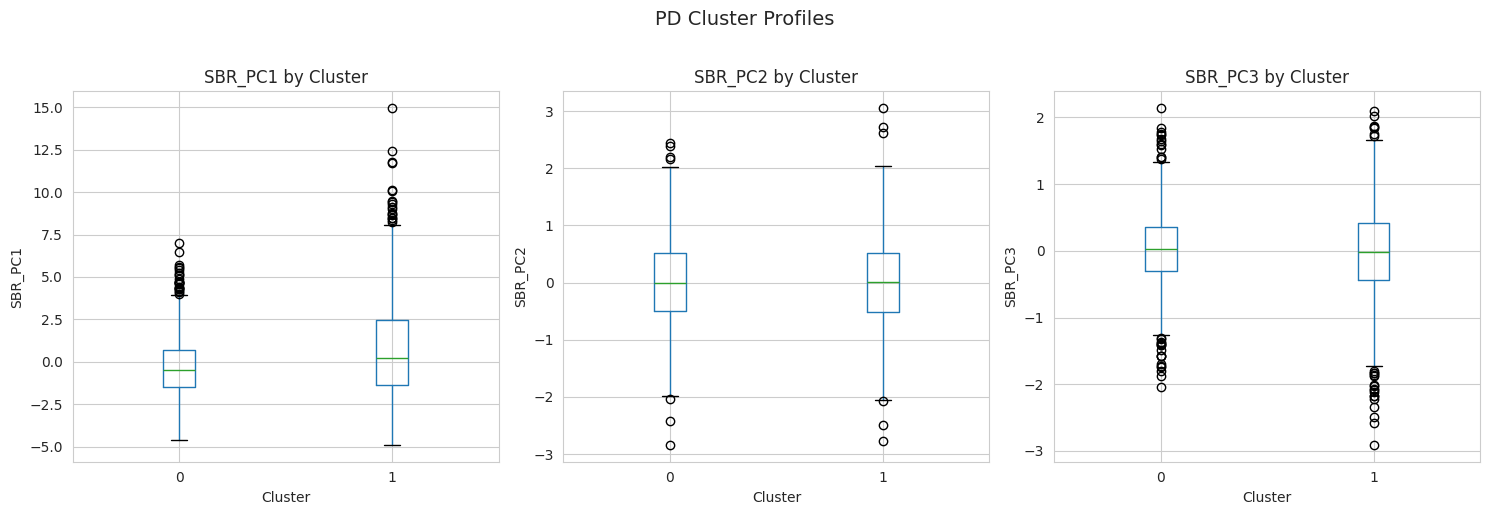

In [18]:
# Create profile plots for continuous variables
profile_vars = [v for v in ['Age', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3'] if v in df_pd_final.columns]

if len(profile_vars) > 0:
    fig, axes = plt.subplots(1, len(profile_vars), figsize=(5*len(profile_vars), 5))
    if len(profile_vars) == 1:
        axes = [axes]
    
    for ax, var in zip(axes, profile_vars):
        df_pd_final.boxplot(column=var, by='cluster', ax=ax)
        ax.set_title(f'{var} by Cluster')
        ax.set_xlabel('Cluster')
        ax.set_ylabel(var)
    
    plt.suptitle('PD Cluster Profiles', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('output/pd_cluster_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()

## 15. Cluster Centroids in Latent Space

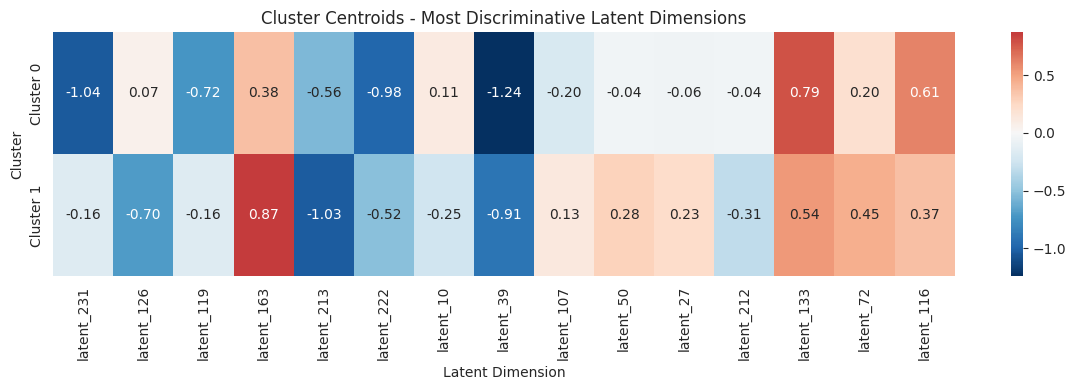


Most Discriminative Latent Dimensions:
  latent_231: Std across clusters = 0.6240
  latent_126: Std across clusters = 0.5441
  latent_119: Std across clusters = 0.4024
  latent_163: Std across clusters = 0.3515
  latent_213: Std across clusters = 0.3327
  latent_222: Std across clusters = 0.3251
  latent_10: Std across clusters = 0.2528
  latent_39: Std across clusters = 0.2379
  latent_107: Std across clusters = 0.2324
  latent_50: Std across clusters = 0.2263
  latent_27: Std across clusters = 0.2015
  latent_212: Std across clusters = 0.1895
  latent_133: Std across clusters = 0.1781
  latent_72: Std across clusters = 0.1743
  latent_116: Std across clusters = 0.1697


In [19]:
# Compute and visualize cluster centroids in latent space
centroids = []
for k in range(OPTIMAL_K):
    cluster_mask = df_pd_final['cluster'] == k
    centroid = df_pd_final.loc[cluster_mask, ACTIVE_FEATURES].mean()
    centroids.append(centroid)

df_centroids = pd.DataFrame(centroids, index=[f'Cluster {k}' for k in range(OPTIMAL_K)])

# Find most discriminative dimensions
centroid_std = df_centroids.std()
top_dims = centroid_std.nlargest(15).index.tolist()

# Heatmap of top discriminative dimensions
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_centroids[top_dims], annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Cluster Centroids - Most Discriminative Latent Dimensions')
ax.set_xlabel('Latent Dimension')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('output/pd_cluster_centroids_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMost Discriminative Latent Dimensions:")
for dim in top_dims:
    print(f"  {dim}: Std across clusters = {centroid_std[dim]:.4f}")

## 16. Summary and Conclusions

In [20]:
print("=" * 60)
print("PD SUBJECT CLUSTERING ANALYSIS - SUMMARY")
print("=" * 60)

print(f"\n1. Dataset:")
print(f"   - Total PD samples (training): {len(df_pd_final)}")
print(f"   - Unique PD patients: {df_pd_final['PATNO'].nunique()}")

print(f"\n2. Feature Space:")
print(f"   - Active latent dimensions: {len(ACTIVE_FEATURES)}")
print(f"   - PCA applied: No (β-VAE dimensions are independent)")

print(f"\n3. Best Clustering:")
print(f"   - Algorithm: {best_algo}")
print(f"   - Number of clusters: {OPTIMAL_K}")
print(f"   - Silhouette Score: {clustering_results[best_algo]['metrics']['silhouette']:.4f}")
print(f"   - Davies-Bouldin Index: {clustering_results[best_algo]['metrics']['davies_bouldin']:.4f}")
print(f"   - Calinski-Harabasz Index: {clustering_results[best_algo]['metrics']['calinski_harabasz']:.2f}")

print(f"\n4. Cluster Sizes:")
for k in range(OPTIMAL_K):
    count = (df_pd_final['cluster'] == k).sum()
    pct = count / len(df_pd_final) * 100
    print(f"   - Cluster {k}: {count} ({pct:.1f}%)")

print(f"\n5. Correlation with Known Factors:")
if correlation_results:
    for res in correlation_results:
        status = "SIGNIFICANT" if res['p-value'] < 0.05 else "not significant"
        print(f"   - {res['Factor']}: p={res['p-value']:.4f} ({status})")

print("\n" + "=" * 60)
print("NEXT STEPS:")
print("=" * 60)
print("1. Investigate clinical/phenotypic differences between clusters")
print("2. Correlate with disease progression data (if available)")
print("3. Validate on external cohorts")
print("4. Explore the most discriminative latent dimensions")

PD SUBJECT CLUSTERING ANALYSIS - SUMMARY

1. Dataset:
   - Total PD samples (training): 2030
   - Unique PD patients: 1136

2. Feature Space:
   - Active latent dimensions: 67
   - PCA applied: No (β-VAE dimensions are independent)

3. Best Clustering:
   - Algorithm: GMM
   - Number of clusters: 2
   - Silhouette Score: 0.1280
   - Davies-Bouldin Index: 6.1026
   - Calinski-Harabasz Index: 47.84

4. Cluster Sizes:
   - Cluster 0: 1468 (72.3%)
   - Cluster 1: 562 (27.7%)

5. Correlation with Known Factors:
   - Manufacturer: p=0.0000 (SIGNIFICANT)
   - SBR_PC1: p=0.0000 (SIGNIFICANT)
   - SBR_PC2: p=0.9974 (not significant)
   - SBR_PC3: p=0.0069 (SIGNIFICANT)

NEXT STEPS:
1. Investigate clinical/phenotypic differences between clusters
2. Correlate with disease progression data (if available)
3. Validate on external cohorts
4. Explore the most discriminative latent dimensions


## 17. Save Results

In [21]:
# Save clustered PD data
output_path = 'output/pd_clustering_results.csv'
df_pd_final.to_csv(output_path, index=False)
print(f"Saved clustered PD data to: {output_path}")

# Save clustering metrics
metrics_summary = pd.DataFrame([
    {'Algorithm': algo, **result['metrics']}
    for algo, result in clustering_results.items()
])
metrics_summary.to_csv('output/pd_clustering_metrics.csv', index=False)
print(f"Saved clustering metrics to: output/pd_clustering_metrics.csv")

# Save correlation results
if correlation_results:
    df_corr.to_csv('output/pd_cluster_factor_correlations.csv', index=False)
    print(f"Saved factor correlations to: output/pd_cluster_factor_correlations.csv")

Saved clustered PD data to: output/pd_clustering_results.csv
Saved clustering metrics to: output/pd_clustering_metrics.csv
Saved factor correlations to: output/pd_cluster_factor_correlations.csv
